In [2]:
import numpy as np
import torch
import torch.nn as nn
from torch.autograd.functional import jvp
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons, make_s_curve

random_state = 42

In [3]:
class Encoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super(Encoder, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim)
        )
    
    def forward(self, x):
        return self.fc(x)

class Decoder(nn.Module):
    def __init__(self, latent_dim, output_dim):
        super(Decoder, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, output_dim)
        )
    
    def forward(self, z):
        return self.fc(z)

class Autoencoder(nn.Module):
    def __init__(self, encoder, decoder, data_dim, latent_dim):
        super(Autoencoder, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.data_dim = data_dim
        self.latent_dim = latent_dim
    
    def forward(self, x):
        # Encode the input data
        z = self.encoder(x)
        
        # Decode the latent representation
        x_reconstructed = self.decoder(z)
        
        return x_reconstructed
    
    def encode(self, x):
        # Encode the input data to get the latent representation
        with torch.no_grad():
            z = self.encoder(x)
        return z
    
    def decode(self, z):
        # Decode the latent representation to get the reconstructed data
        with torch.no_grad():
            x_reconstructed = self.decoder(z)
        return x_reconstructed
    
    def get_loss(self, x):
        # Compute the reconstruction loss
        x_reconstructed = self.forward(x)
        loss = nn.MSELoss()(x_reconstructed, x)
        return loss
    
    def train(self, data, epochs=1000, batch_size=64, learning_rate=0.001):        
        # Define loss function and optimizer
        optimizer = torch.optim.Adam(self.parameters(), lr=learning_rate)
        
        # Training loop
        for epoch in range(epochs):
            for i in range(0, len(data), batch_size):
                batch_data = data[i:i+batch_size]

                # Compute loss
                loss = self.get_loss(batch_data)
                
                # Backward pass and optimization
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            
            if (epoch + 1) % 100 == 0:
                print(f'Epoch [{epoch + 1}/{epochs}], Loss: {loss.item():.4f}')
    
class IsometricAutoencoder(Autoencoder):
    def __init__(self, encoder, decoder, data_dim, latent_dim, lambda_iso=0.1):
        super(IsometricAutoencoder, self).__init__(encoder, decoder, data_dim, latent_dim)
        self.encoder = encoder
        self.decoder = decoder
        self.data_dim = data_dim
        self.latent_dim = latent_dim
        self.lambda_iso = lambda_iso
    
    def get_loss(self, x):
        z = self.encoder(x)

        distortion = self.isometry_loss(self.decoder, z)

        x_reconstructed = self.decoder(z)
        mse = nn.MSELoss()(x_reconstructed, x)

        loss = mse + self.lambda_iso * distortion
        return loss
    
    def isometry_loss(self, func, z, epsilon=1e-8):
        """
        z: (batch_size, latent_dim) latent vectors sampled from Piso
        """
        
        # Sample u ~ Uniform(S^{d-1}), i.e., unit vector on sphere
        u = torch.randn_like(z)
        u = u / (u.norm(dim=1, keepdim=True) + epsilon)

        # Compute Jv = df(z) @ u
        Jv = jvp(func, z, u, create_graph=True)[1]

        # Compute norm of Jv and apply the isometric loss
        Jv_norm = Jv.norm(dim=1)
        loss = ((Jv_norm - 1.0) ** 2).mean()

        loss = (Jv)
        
        return loss
    
    
class ScaledIsometricAutoencoder(Autoencoder):
    def __init__(self, encoder, decoder, data_dim, latent_dim, lambda_iso=0.1):
        super(ScaledIsometricAutoencoder, self).__init__(encoder, decoder, data_dim, latent_dim)
        self.encoder = encoder
        self.decoder = decoder
        self.data_dim = data_dim
        self.latent_dim = latent_dim
        self.lambda_iso = lambda_iso
    
    def get_loss(self, x):
        z = self.encoder(x)

        distortion = self.relaxed_distortion_measure(self.decoder, z)

        x_reconstructed = self.decoder(z)
        mse = nn.MSELoss()(x_reconstructed, x)

        loss = mse + self.lambda_iso * distortion
        return loss
    
    def relaxed_distortion_measure(self, func, z, eta=0.2, create_graph=True):
        '''
        func: decoder that maps "latent value z" to "data", where z.size() == (batch_size, latent_dim)
        '''
        bs = len(z)
        z_perm = z[torch.randperm(bs)] #?
        alpha = (torch.rand(bs) * (1 + 2*eta) - eta).unsqueeze(1).to(z) #?
        z_augmented = alpha*z + (1-alpha)*z_perm #?
        # z_augmented = z
        v = torch.randn(z.size()).to(z)
        Jv = torch.autograd.functional.jvp(
            func, z_augmented, v=v, create_graph=create_graph)[1]
        TrG = torch.sum(Jv.view(bs, -1)**2, dim=1).mean()
        JTJv = (torch.autograd.functional.vjp(
            func, z_augmented, v=Jv, create_graph=create_graph)[1]).view(bs, -1)
        TrG2 = torch.sum(JTJv**2, dim=1).mean()
        return TrG2/TrG**2


class ConformalAutoencoder(Autoencoder):
    def __init__(self, encoder, decoder, data_dim, latent_dim, lambda_iso=0.1):
        super(ConformalAutoencoder, self).__init__(encoder, decoder, data_dim, latent_dim)
        self.encoder = encoder
        self.decoder = decoder
        self.data_dim = data_dim
        self.latent_dim = latent_dim
        self.lambda_iso = lambda_iso
    
    def get_loss(self, x):
        z = self.encoder(x)

        distortion = self.conformal_angle_loss(self.decoder, z)

        x_reconstructed = self.decoder(z)
        mse = nn.MSELoss()(x_reconstructed, x)

        loss = mse + self.lambda_iso * distortion
        return loss
    
    def conformal_loss(self, f: callable, z: torch.Tensor) -> torch.Tensor:
        """
        Differentiable conformal loss measuring deviation from angle-preserving properties.
        
        Args:
            f: Differentiable function (typically neural network)
            z: Input tensor (must have requires_grad=True)
            
        Returns:
            Scalar loss value (lower means more conformal)
        """
        # Compute Jacobian matrix
        # J = torch.autograd.functional.jacobian(f, z, create_graph=True)
        B, in_dim = z.shape
        z = z.clone().detach().requires_grad_(True)

        y = f(z)  # (B, out_dim)
        out_dim = y.shape[1]

        jacobian = []

        for i in range(out_dim):
            grads = torch.autograd.grad(
                y[:, i].sum(), z, create_graph=True, retain_graph=True
            )[0]  # shape (B, in_dim)
            jacobian.append(grads.unsqueeze(1))  # shape (B, 1, in_dim)

        J = torch.cat(jacobian, dim=1)
        
        # Handle batch dimensions and reshape for matrix multiplication
        if z.dim() > 1:  # Batched inputs
            J = J.flatten(start_dim=1, end_dim=-2)
        
        # Compute J^T J and expected conformal scaling
        JTJ = torch.bmm(J.transpose(1,2), J)
        n = JTJ.size(1)
        trace = JTJ.diagonal(offset=0, dim1=-1, dim2=-2).sum(-1)
        lambda_scalar = trace / n
        print(z.shape)
        print(J.shape)
        print(lambda_scalar.shape)
        
        # Create identity matrix matching device/dtype
        I = torch.eye(n, device=z.device, dtype=z.dtype)
        I = I.reshape((1, n, n))
        I = I.repeat(JTJ.shape[0], 1, 1)
        
        # Calculate Frobenius norm of deviation from conformal condition
        # reshape lambda_scalar to (batch_size, 2,2)
        lambda_scalar = lambda_scalar.reshape((-1, 1, 1))
        lambda_scalar = lambda_scalar.repeat(1, n, n)
        loss = torch.norm(JTJ - lambda_scalar * I, p='fro')**2
        
        return loss
    
    def conformal_angle_loss(self, f, z):
        z_perm = z[torch.randperm(z.size(0))]
        
        x = f(z)
        x_perm = f(z_perm)

        cos_angle_z = torch.nn.functional.cosine_similarity(z, z_perm)
        cos_angle_x = torch.nn.functional.cosine_similarity(x, x_perm)

        loss = torch.mean((cos_angle_z - cos_angle_x) ** 2)
        return loss

    
    # def generalized_conformality_loss(self, f, x):
    #     """
    #     Conformality loss for any f: R^n -> R^m (n < m), encouraging angle preservation.
        
    #     Args:
    #         f: differentiable function from (N, in_dim) -> (N, out_dim)
    #         x: input tensor of shape (N, in_dim)
            
    #     Returns:
    #         scalar loss
    #     """
    #     x = x.requires_grad_(True)
    #     fx = f(x)  # shape (N, out_dim)
    #     N, in_dim = x.shape
    #     out_dim = fx.shape[1]

    #     # Compute Jacobian: for each output dim, compute gradient wrt x
    #     grads = []
    #     for i in range(out_dim):
    #         grad = torch.autograd.grad(fx[:, i], x, grad_outputs=torch.ones_like(fx[:, i]), create_graph=True)[0]
    #         grads.append(grad)  # list of (N, in_dim)
        
    #     # Stack into (N, out_dim, in_dim) Jacobian tensor
    #     J = torch.stack(grads, dim=1)

    #     # Compute Gram matrix G = J^T @ J (per sample): shape (N, in_dim, in_dim)
    #     J_T = J.transpose(1, 2)
    #     G = torch.bmm(J_T, J)

    #     # Target: G ≈ s² * I → we normalize and minimize deviation from scaled identity
    #     eye = torch.eye(in_dim, device=x.device).unsqueeze(0)  # shape (1, in_dim, in_dim)
        
    #     # Normalize each Gram matrix by its trace
    #     trace = torch.trace(G) if in_dim == 1 else G.diagonal(dim1=1, dim2=2).sum(dim=1, keepdim=True).unsqueeze(-1)
    #     G_normalized = G / (trace + 1e-8)

    #     loss = torch.mean((G_normalized - eye) ** 2)
    #     return loss

In [4]:
def make_halve_sphere(n_samples=1000, noise=0.1, random_state=None):
    """
    Generate a half-sphere dataset.
    """
    if random_state is not None:
        np.random.seed(random_state)
    
    # Generate random points on a sphere
    phi = np.random.uniform(0, np.pi, n_samples)
    theta = np.random.uniform(0, 2 * np.pi, n_samples)
    
    x = np.sin(phi) * np.cos(theta)
    y = np.sin(phi) * np.sin(theta)
    z = np.cos(phi)
    
    # Keep only the upper hemisphere
    mask = z >= 0
    x = x[mask]
    y = y[mask]
    z = z[mask]
    
    # Add noise
    noise_x = np.random.normal(0, noise, x.shape)
    noise_y = np.random.normal(0, noise, y.shape)
    noise_z = np.random.normal(0, noise, z.shape)
    
    x += noise_x
    y += noise_y
    z += noise_z

    labels = z
    
    return np.column_stack((x, y, z)), labels

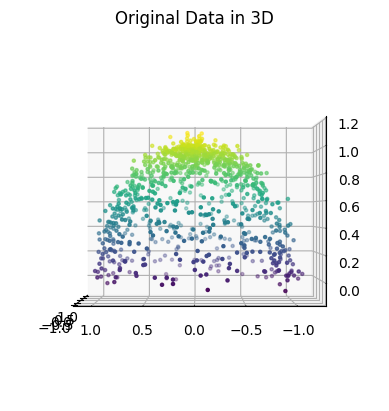

In [5]:
data, labels = make_halve_sphere(n_samples=2000, noise=0.05, random_state=random_state)
data = torch.tensor(data, dtype=torch.float32)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data[:, 0], data[:, 1], data[:, 2], c=labels, s=5)
ax.set_title("Original Data in 3D")
ax.view_init(0, 180, 0)
plt.show()

In [6]:
encoder = Encoder(input_dim=3, latent_dim=2)
decoder = Decoder(latent_dim=2, output_dim=3)
isotropic_autoencoder = ConformalAutoencoder(encoder, decoder, data_dim=3, latent_dim=2, lambda_iso=0.01)
isotropic_autoencoder.train(data, epochs=1000)

Epoch [100/1000], Loss: 0.0020
Epoch [200/1000], Loss: 0.0021
Epoch [300/1000], Loss: 0.0018
Epoch [400/1000], Loss: 0.0016
Epoch [500/1000], Loss: 0.0020
Epoch [600/1000], Loss: 0.0017
Epoch [700/1000], Loss: 0.0010
Epoch [800/1000], Loss: 0.0011
Epoch [900/1000], Loss: 0.0014
Epoch [1000/1000], Loss: 0.0021


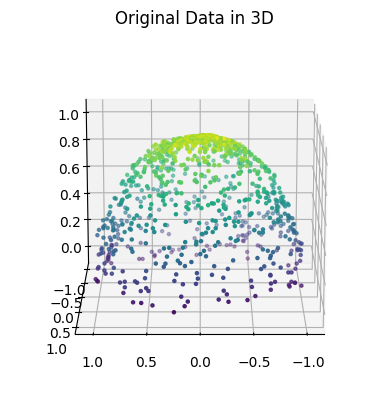

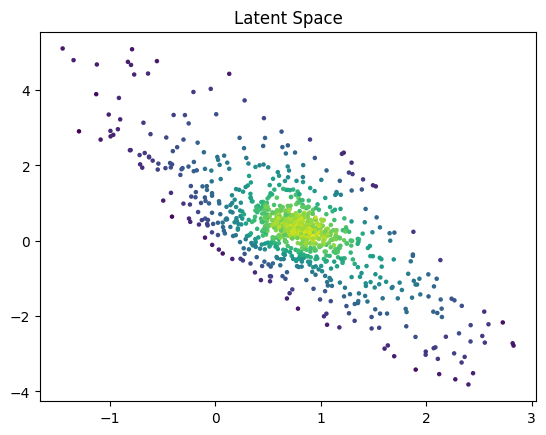

In [7]:
#Encode the data
encoded_data = isotropic_autoencoder.encode(data)
# Decode the data
decoded_data = isotropic_autoencoder.decode(encoded_data)

# Visualize the reconstruction
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(decoded_data[:, 0], decoded_data[:, 1], decoded_data[:, 2], c=labels, cmap='viridis', s=5)
ax.set_title("Original Data in 3D")
ax.view_init(15, 90, 0)
plt.show()
# Visualize the latent space
plt.scatter(encoded_data[:, 0], encoded_data[:, 1], c=labels, cmap='viridis', s=5)
plt.title("Latent Space")
plt.show()

In [8]:
num = 900
J = torch.zeros((num, 2, 2))
for i in range(num):
    latent = encoder(data[i:i+1])
    jac = torch.autograd.functional.jacobian(decoder, latent)
    jac = jac[0,:,0,:]
    J[i] = jac.T @ jac
print(J.mean(dim=0))
print(J.std(dim=0))

tensor([[2.5052, 0.7131],
        [0.7131, 0.9865]])
tensor([[1.0593, 0.2937],
        [0.2937, 0.5972]])


In [9]:
val_data, val_labels = make_halve_sphere(n_samples=2000, noise=0.05, random_state=random_state)
val_data = torch.tensor(val_data, dtype=torch.float32)
reconstruction = isotropic_autoencoder(val_data)
recon_error = nn.MSELoss()(reconstruction, val_data)
print(f"Reconstruction Error: {recon_error.item():.8f}")

Reconstruction Error: 0.00101468


In [10]:
encoder = Encoder(input_dim=3, latent_dim=2)
decoder = Decoder(latent_dim=2, output_dim=3)
isotropic_autoencoder = ConformalAutoencoder(encoder, decoder, data_dim=3, latent_dim=2, lambda_iso=0.1)
isotropic_autoencoder.train(data, epochs=1000)

Epoch [100/1000], Loss: 0.0146
Epoch [200/1000], Loss: 0.0099
Epoch [300/1000], Loss: 0.0113
Epoch [400/1000], Loss: 0.0073
Epoch [500/1000], Loss: 0.0127
Epoch [600/1000], Loss: 0.0150
Epoch [700/1000], Loss: 0.0098
Epoch [800/1000], Loss: 0.0153
Epoch [900/1000], Loss: 0.0074
Epoch [1000/1000], Loss: 0.0088


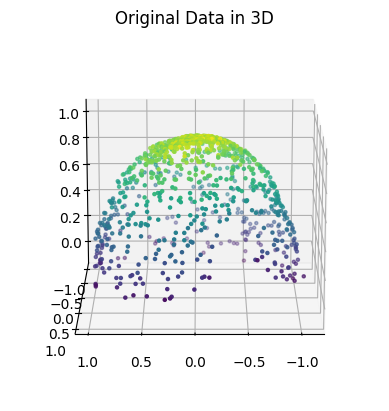

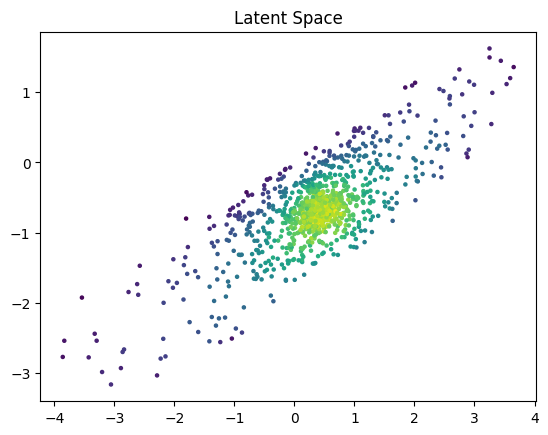

In [11]:
#Encode the data
encoded_data = isotropic_autoencoder.encode(data)
# Decode the data
decoded_data = isotropic_autoencoder.decode(encoded_data)

# Visualize the reconstruction
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(decoded_data[:, 0], decoded_data[:, 1], decoded_data[:, 2], c=labels, cmap='viridis', s=5)
ax.set_title("Original Data in 3D")
ax.view_init(15, 90, 0)
plt.show()
# Visualize the latent space
plt.scatter(encoded_data[:, 0], encoded_data[:, 1], c=labels, cmap='viridis', s=5)
plt.title("Latent Space")
plt.show()

In [12]:
num = 900
J = torch.zeros((num, 2, 2))
for i in range(num):
    latent = encoder(data[i:i+1])
    jac = torch.autograd.functional.jacobian(decoder, latent)
    jac = jac[0,:,0,:]
    J[i] = jac.T @ jac
print(J.mean(dim=0))
print(J.std(dim=0))

tensor([[ 1.3060, -0.5057],
        [-0.5057,  1.9295]])
tensor([[0.7496, 0.3656],
        [0.3656, 0.8298]])


In [13]:
val_data, val_labels = make_halve_sphere(n_samples=2000, noise=0.05, random_state=random_state)
val_data = torch.tensor(val_data, dtype=torch.float32)
reconstruction = isotropic_autoencoder(val_data)
recon_error = nn.MSELoss()(reconstruction, val_data)
print(f"Reconstruction Error: {recon_error.item():.8f}")

Reconstruction Error: 0.00326641


In [14]:
encoder = Encoder(input_dim=3, latent_dim=2)
decoder = Decoder(latent_dim=2, output_dim=3)
isotropic_autoencoder = ConformalAutoencoder(encoder, decoder, data_dim=3, latent_dim=2, lambda_iso=1.0)
isotropic_autoencoder.train(data, epochs=1000)

Epoch [100/1000], Loss: 0.0455
Epoch [200/1000], Loss: 0.0482
Epoch [300/1000], Loss: 0.0339
Epoch [400/1000], Loss: 0.0444
Epoch [500/1000], Loss: 0.0373
Epoch [600/1000], Loss: 0.0430
Epoch [700/1000], Loss: 0.0487
Epoch [800/1000], Loss: 0.0420
Epoch [900/1000], Loss: 0.0455
Epoch [1000/1000], Loss: 0.0375


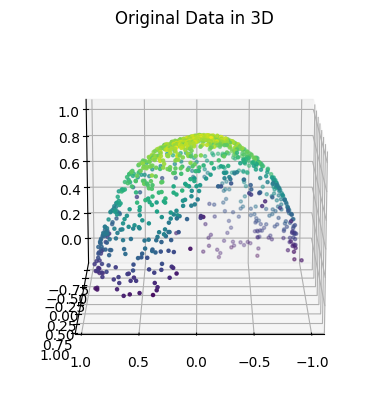

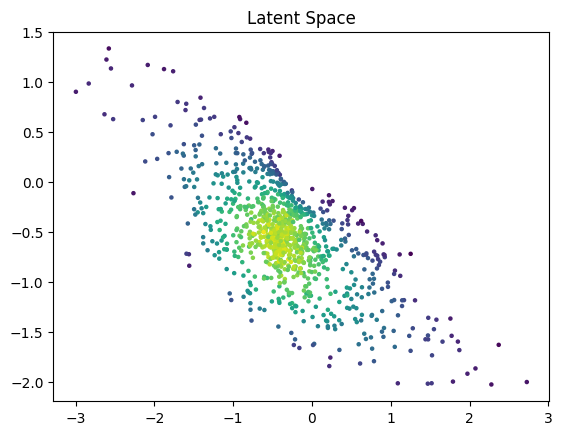

In [15]:
#Encode the data
encoded_data = isotropic_autoencoder.encode(data)
# Decode the data
decoded_data = isotropic_autoencoder.decode(encoded_data)

# Visualize the reconstruction
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(decoded_data[:, 0], decoded_data[:, 1], decoded_data[:, 2], c=labels, cmap='viridis', s=5)
ax.set_title("Original Data in 3D")
ax.view_init(15, 90, 0)
plt.show()
# Visualize the latent space
plt.scatter(encoded_data[:, 0], encoded_data[:, 1], c=labels, cmap='viridis', s=5)
plt.title("Latent Space")
plt.show()

In [16]:
num = 900
J = torch.zeros((num, 2, 2))
for i in range(num):
    latent = encoder(data[i:i+1])
    jac = torch.autograd.functional.jacobian(decoder, latent)
    jac = jac[0,:,0,:]
    J[i] = jac.T @ jac
print(J.mean(dim=0))
print(J.std(dim=0))

tensor([[1.4211, 0.0122],
        [0.0122, 1.3730]])
tensor([[1.2041, 0.5936],
        [0.5936, 1.0328]])


In [17]:
val_data, val_labels = make_halve_sphere(n_samples=2000, noise=0.05, random_state=random_state)
val_data = torch.tensor(val_data, dtype=torch.float32)
reconstruction = isotropic_autoencoder(val_data)
recon_error = nn.MSELoss()(reconstruction, val_data)
print(f"Reconstruction Error: {recon_error.item():.8f}")

Reconstruction Error: 0.02499741


In [18]:
encoder = Encoder(input_dim=3, latent_dim=2)
decoder = Decoder(latent_dim=2, output_dim=3)
isotropic_autoencoder = ConformalAutoencoder(encoder, decoder, data_dim=3, latent_dim=2, lambda_iso=10.0)
isotropic_autoencoder.train(data, epochs=1000)

Epoch [100/1000], Loss: 0.0696
Epoch [200/1000], Loss: 0.0547
Epoch [300/1000], Loss: 0.0595
Epoch [400/1000], Loss: 0.0522
Epoch [500/1000], Loss: 0.0558
Epoch [600/1000], Loss: 0.0513
Epoch [700/1000], Loss: 0.0596
Epoch [800/1000], Loss: 0.0566
Epoch [900/1000], Loss: 0.0522
Epoch [1000/1000], Loss: 0.0586


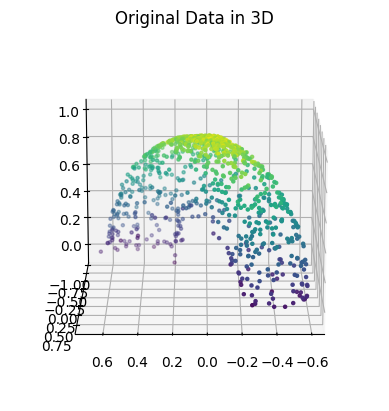

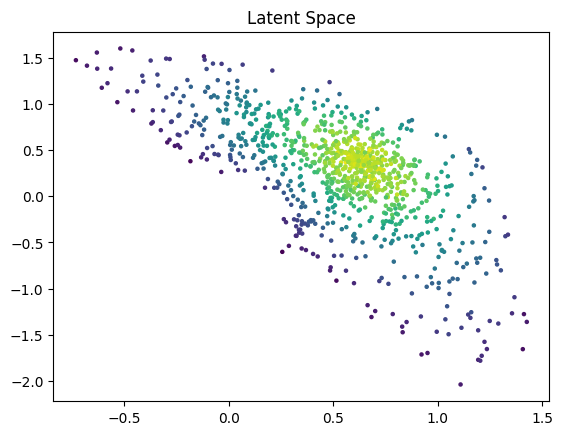

In [19]:
#Encode the data
encoded_data = isotropic_autoencoder.encode(data)
# Decode the data
decoded_data = isotropic_autoencoder.decode(encoded_data)

# Visualize the reconstruction
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(decoded_data[:, 0], decoded_data[:, 1], decoded_data[:, 2], c=labels, cmap='viridis', s=5)
ax.set_title("Original Data in 3D")
ax.view_init(15, 90, 0)
plt.show()
# Visualize the latent space
plt.scatter(encoded_data[:, 0], encoded_data[:, 1], c=labels, cmap='viridis', s=5)
plt.title("Latent Space")
plt.show()

In [20]:
num = 900
J = torch.zeros((num, 2, 2))
for i in range(num):
    latent = encoder(data[i:i+1])
    jac = torch.autograd.functional.jacobian(decoder, latent)
    jac = jac[0,:,0,:]
    J[i] = jac.T @ jac
print(J.mean(dim=0))
print(J.std(dim=0))

tensor([[1.3681, 0.0258],
        [0.0258, 1.3646]])
tensor([[0.7032, 0.4393],
        [0.4393, 0.7287]])


In [21]:
val_data, val_labels = make_halve_sphere(n_samples=2000, noise=0.05, random_state=random_state)
val_data = torch.tensor(val_data, dtype=torch.float32)
reconstruction = isotropic_autoencoder(val_data)
recon_error = nn.MSELoss()(reconstruction, val_data)
print(f"Reconstruction Error: {recon_error.item():.8f}")

Reconstruction Error: 0.05304065
